# ML Model Development: Shark Attack Fatality Risk Predictor

##### Every year, shark attacks occur around the world. My goal with this project was to identify high-risk factors to help improve safety planning for marine and coastal activities. I’ve built a predictive model to identify which incidents between sharks and people are most likely to be fatal. I treated this as a binary classification problem where a positive (fatal) prediction would indicate high risk of fatality in the event of a shark attack.

In [2]:
#Import necessary libraries

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## Prepare the Cleaned Data for Machine Learning

In [4]:
# Load the dataset.
df = pd.read_csv('../data/processed/03_gsaf_ml_data.csv')

In [5]:
# Lood at data structure, types, and missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5771 entries, 0 to 5770
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         5771 non-null   int64  
 1   Type         5771 non-null   object 
 2   Country      5771 non-null   object 
 3   Activity     5771 non-null   object 
 4   Sex          5771 non-null   object 
 5   Age          5771 non-null   float64
 6   Fatal        5771 non-null   int64  
 7   Species      5771 non-null   object 
 8   Age_missing  5771 non-null   int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 405.9+ KB


In [6]:
# Inspect the first five rows of the dataset.
df.head()

,Year,Type,Country,Activity,Sex,Age,Fatal,Species,Age_missing
0,2016,Unprovoked,AUSTRALIA,scuba diving,M,24.0,0,great white,1
1,2025,Unprovoked,USA,swimming,F,55.0,1,great white,0
2,2025,Unprovoked,USA,surfing,M,24.0,0,great white,1
3,2025,Provoked,USA,Other,M,24.0,0,blacktip reef,0
4,2025,Unprovoked,AUSTRALIA,swimming,M,26.0,0,bull,0


In [7]:
# Check distribution of the target vector, showing the percentage of the data where Fatal = True (1)
print(f"\nFatal rate: {df['Fatal'].mean():.2%}")


Fatal rate: 19.51%


In [8]:
# Create a feature matrix "X" and a target vector "y".
X = df.drop('Fatal', axis = 1)
y = df['Fatal']

In [9]:
# Identify the categorical and numeric features.
categorical_features = list(df.select_dtypes(include = ["object"]))
print(f"\nCategorical Features: {categorical_features}")

numeric_features = list(df.select_dtypes(include=['number']).columns.drop('Fatal'))
print(f"Numeric Features: {numeric_features}")


Categorical Features: ['Type', 'Country', 'Activity', 'Sex', 'Species']
Numeric Features: ['Year', 'Age', 'Age_missing']


In [10]:
# Split the data into training (80%) and testing (20%) sets before preprocessing to avoid data leakage.
# Use stratified splitting to make sure both train and test sets have the same class distribution.
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
# Check the number of rows in each set.
print(f"\nRows in Training Set: {len(X_train)}")
print(f"Rows in Test Set: {len(X_test)}")
# Check "Fatal" distribution for the test set.
print(f"\nTest Fatal rate:\n{y_test.mean():.2%}")


Rows in Training Set: 4616
Rows in Test Set: 1155

Test Fatal rate:
19.48%


## Build a Pipeline for Data Processing and a Baseline Logistic Regression Model

In [13]:
# Set up the data preprocessor pipeline to use throughout this notebook, using ColumnTransformer to combine the two transformers needed.

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)  
    ]
)       

# Set up a complete pipeline for a logistic regression classification model with class_weight='balanced' to account for the moderate data imbalance.
# random_state=42 is used throughout the notebook to create reproducible results.
log_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))  
])

# Fit the pipeline and make predictions
log_reg_pipeline.fit(X_train, y_train)
y_pred = log_reg_pipeline.predict(X_test)

print("\033[1;31m\nPIPELINE TRAINED - MISSION ACCOMPLISHED!\033[0m")


PIPELINE TRAINED - MISSION ACCOMPLISHED!


## Choose Appropriate Metrics for the Problem and the Model:
##### Metrics were chosen based on binary classification involving categorical data. 

In [15]:
# Print test scores to evaluate model.
print("\nLogistic Regression Results:")

# Print chosen metrics.
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred):.4f}") # Ratio of correct predictions to total.
print(f"Precision: {precision_score(y_test, y_pred):.4f}") # Accuracy of positive predictions.
print(f"Recall:    {recall_score(y_test, y_pred):.4f}") # True positive rate.
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}") # Harmonic mean of precision and recall.
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")


Logistic Regression Results:

Accuracy:  0.7732
Precision: 0.4541
Recall:    0.8133
F1 Score:  0.5828

Confusion Matrix:
[[710 220]
 [ 42 183]]


## Cross Validation

In [17]:
# Apply cross validation using Stratified K-Fold to preserve class distribution in each fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up cross validation metrics 
cv_accuracy = cross_val_score(log_reg_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
cv_precision = cross_val_score(log_reg_pipeline, X_train, y_train, cv=cv, scoring='precision')
cv_recall = cross_val_score(log_reg_pipeline, X_train, y_train, cv=cv, scoring='recall')
cv_f1 = cross_val_score(log_reg_pipeline, X_train, y_train, cv=cv, scoring='f1')

In [18]:
# Print the results.
print(f"\n5-Fold Cross-Validation Results:\n")
print(f"  Accuracy:  {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std()*2:.4f})")
print(f"  Precision: {cv_precision.mean():.4f} (+/- {cv_precision.std()*2:.4f})")
print(f"  Recall:    {cv_recall.mean():.4f} (+/- {cv_recall.std()*2:.4f})")
print(f"  F1 Score:  {cv_f1.mean():.4f} (+/- {cv_f1.std()*2:.4f})")


5-Fold Cross-Validation Results:

  Accuracy:  0.7667 (+/- 0.0143)
  Precision: 0.4457 (+/- 0.0192)
  Recall:    0.7991 (+/- 0.0384)
  F1 Score:  0.5721 (+/- 0.0203)


## Try Other Models

In [20]:
# Choose a number of models that may be a good fit for the problem and store them in a dictionary.
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVC': SVC(class_weight='balanced', random_state=42)
}

# Make a list to hold results. 
models_results = []

# Compare the 5 models using cross validation in a for loop, then print the results.
for name, model in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    
    # Cross-validation.
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
    # Fit and test.
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Send results to the list.
    models_results.append({
        'Model': name,
        'CV F1 (mean)': cv_scores.mean(),
        'CV F1 (std)': cv_scores.std(),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test Precision': precision_score(y_test, y_pred),
        'Test Recall': recall_score(y_test, y_pred),
        'Test F1': f1_score(y_test, y_pred)
    })
# Create a dataframe of results.    
models_results_df = pd.DataFrame(models_results).round(4)
print("\033[1;31m\nCOMPARISON COMPLETE!\033[0m")


COMPARISON COMPLETE!


In [21]:
# Print results.
print("\nModel Comparison Results:")
print(models_results_df.to_string(index=False))


Model Comparison Results:
              Model  CV F1 (mean)  CV F1 (std)  Test Accuracy  Test Precision  Test Recall  Test F1
Logistic Regression        0.5721       0.0102         0.7732          0.4541       0.8133   0.5828
      Decision Tree        0.4925       0.0213         0.7602          0.4240       0.6444   0.5115
      Random Forest        0.4666       0.0372         0.8364          0.6169       0.4222   0.5013
  Gradient Boosting        0.4311       0.0323         0.8424          0.6838       0.3556   0.4678
                SVC        0.5765       0.0087         0.7680          0.4499       0.8578   0.5902


## Build the Three Best Models Using Hyperparameter Tuning

### Logistic Regression - Using GridSearchCV

In [24]:
# Import GridSearchCV for hyperparameter tuning.
from sklearn.model_selection import GridSearchCV
# Recall will be prioritized and f2_score will replace f1, because False Negatives are too costly.
from sklearn.metrics import fbeta_score, make_scorer
f2_score = make_scorer(fbeta_score, beta=2)

print("\nGRID SEARCH:")

# Build the logistic regression pipeline, using penalty='l2' so that "C" is not ignored.
lr = LogisticRegression(class_weight='balanced', penalty='l2', random_state=42)

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lr)
])
# Define the logistic regression parameter grid.
param_grid_lr = {
    #'classifier__C': [0.01, 0.1, 1, 10, 100], was used initaially but results indicated using higher values
    'classifier__C': [10, 100, 500, 750, 1000],
    'classifier__solver':['newton-cholesky','lbfgs'],
    'classifier__max_iter':[100, 200, 500]
}
# Total combinations: 5x2x2x3 = 60
print(f"Total parameter combinations: {5 * 2 * 3}")

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(
    lr_pipeline,
    param_grid_lr,
    cv=5, # 5 fold cross validation (repeat in all models)
    scoring=f2_score, # recall=2x weight of precision (repeat in all models)
    n_jobs=-1, # Use all CPU cores (repeat in all models)
    verbose=1
)

# Fit the model.
grid_search_lr.fit(X_train, y_train)

# Print the best CV score and parameters.
print(f"Best CV F2 score: {grid_search_lr.best_score_:.4f}")
print(f"Best Parameters:\n{grid_search_lr.best_params_}")


GRID SEARCH:
Total parameter combinations: 30
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV F2 score: 0.6971
Best Parameters:
{'classifier__C': 100, 'classifier__max_iter': 100, 'classifier__solver': 'lbfgs'}


In [25]:
# Evaluate the best logistic regression model on test set.
lr_best_model = grid_search_lr.best_estimator_
y_pred = lr_best_model.predict(X_test)

# Create a print function to avoid repetative code for future models:
def print_results(y_test, y_pred):
    print("\nTEST SCORES:")
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Test Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Test Recall score: {recall_score(y_test, y_pred):.4f}")
    print(f"Test F2 score: {fbeta_score(y_test, y_pred, beta=2):.4f}")
    print(f"Test ROC_AUC score: {roc_auc_score(y_test, y_pred):.4f}")

print_results(y_test, y_pred)


TEST SCORES:
Test Accuracy: 0.7749
Test Precision: 0.4568
Test Recall score: 0.8222
Test F2 score: 0.7088
Test ROC_AUC score: 0.7928


### Decision Tree Classifier - Using GridSearchCV

In [27]:
# Use same methods as used in Logistic Regression.

print("\nGRID SEARCH:")

dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', dt)
])

param_grid_dt = {
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__criterion':['gini', 'entropy']
}
print(f"Total parameter combinations: {4 * 3 * 2}")

grid_search_dt = GridSearchCV(
    dt_pipeline,
    param_grid_dt,
    cv=5,
    scoring=f2_score,
    n_jobs=-1, 
    verbose=1
)

grid_search_dt.fit(X_train, y_train)

# Print the best CV score and parameters:    
print(f"Best CV F2 score: {grid_search_dt.best_score_:.4f}")
print(f"Best Parameters: {grid_search_dt.best_params_}")


GRID SEARCH:
Total parameter combinations: 24
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV F2 score: 0.6623
Best Parameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__min_samples_split': 10}


In [28]:
# Evaluate best model on test set and print results.
dt_best_model = grid_search_dt.best_estimator_
y_pred = dt_best_model.predict(X_test)

print_results(y_test, y_pred)


TEST SCORES:
Test Accuracy: 0.7022
Test Precision: 0.3768
Test Recall score: 0.8089
Test F2 score: 0.6580
Test ROC_AUC score: 0.7426


### SVC - Using RandomizedSearchCV

In [30]:
# Build an SVC (Support Vector Classification) model using RandomizedSearchCV to help narrow down parameters.

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import reciprocal, uniform

print("\nRANDOMIZED SEARCH:")

# Define the pipeline
SVC_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(class_weight='balanced', random_state=42))
])
# Define parameter distributions (not just lists).
param_distributions = {
    'classifier__C': reciprocal(0.1, 1000),
    'classifier__gamma': reciprocal(0.0001, 1),
    'classifier__kernel': ['rbf', 'linear'],
    'classifier__degree': [2,3,4],
    'classifier__class_weight': [None, 'balanced']
}
# Sample 20 combinations
random_search = RandomizedSearchCV(
    SVC_pipeline,
    param_distributions,
    n_iter=20, # Number of parameter settings to sample
    cv=5,
    scoring=f2_score,
    n_jobs=-1,
    verbose=1,
    random_state=42
)
# Fit the model.
random_search.fit(X_train, y_train)

# Print randomized search best CV score and parameters.
print(f"Best CV F2 score: {random_search.best_score_:.4f}")
print(f"Best parameters:\n{random_search.best_params_}")


RANDOMIZED SEARCH:
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV F2 score: 0.7024
Best parameters:
{'classifier__C': 0.6235377135673155, 'classifier__class_weight': 'balanced', 'classifier__degree': 4, 'classifier__gamma': 0.18274508859816008, 'classifier__kernel': 'rbf'}


In [31]:
# Evaluate best model on test set and print results.
SVC_best_model = random_search.best_estimator_
y_pred = SVC_best_model.predict(X_test)

print_results(y_test, y_pred)


TEST SCORES:
Test Accuracy: 0.7697
Test Precision: 0.4522
Test Recall score: 0.8622
Test F2 score: 0.7299
Test ROC_AUC score: 0.8048


### SVC - Using GridSearchCV for Finetuning

In [33]:
# Used same method as previous models.

print("\nGRID SEARCH:")

# Define the pipeline with model hyperparameters from the previous random search results as a guide.
svc = SVC(kernel='rbf', class_weight='balanced', random_state=42) 

# Originally scoring was 'recall', but the highest gamma value was continuously getting pushed to the outer edge here, even as recall got lower.
# My solution was to use F2 scoring (in all models for consistancy) to weigh recall twice as heavily as precision, to avoid overfitting.

svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', svc)
])

# Define parameter grid using the random search results as a guide.
param_grid_svc = {
    'classifier__C': [100, 500, 1000],
    'classifier__gamma': [0.0001, 0.001, 0.01, 0.1, 1]
    #'classifier__degree': [2,3,4] no longer needed because using rbf kernel
}

print(f"Total parameter combinations: {3 * 3}")

grid_search_svc = GridSearchCV(
    svc_pipeline,
    param_grid_svc,
    cv=5,
    scoring=f2_score,
    n_jobs=-1,
    verbose=1
)

grid_search_svc.fit(X_train, y_train)

# Print the best CV score and parameters.
print(f"Best CV F2 score: {grid_search_svc.best_score_:.4f}")
print(f"Best parameters: {grid_search_svc.best_params_}")


GRID SEARCH:
Total parameter combinations: 9
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best CV F2 score: 0.7062
Best parameters: {'classifier__C': 1000, 'classifier__gamma': 0.001}


In [34]:
# Evaluate best model on test set and print results. 
svc_best_model = grid_search_svc.best_estimator_
y_pred = svc_best_model.predict(X_test)

print_results(y_test, y_pred)


TEST SCORES:
Test Accuracy: 0.7481
Test Precision: 0.4270
Test Recall score: 0.8578
Test F2 score: 0.7138
Test ROC_AUC score: 0.7896


## Model Comparison


MODEL COMPARISON AFTER HYPERPARAMETER TUNING:

              Model Accuracy Recall Precision F2 Score ROC_AUC
Logistic Regression   0.7749 0.8222    0.4568   0.7088  0.7928
      Decision Tree   0.7022 0.8089    0.3768   0.6580  0.7426
                SVC   0.7481 0.8578    0.4270   0.7138  0.7896


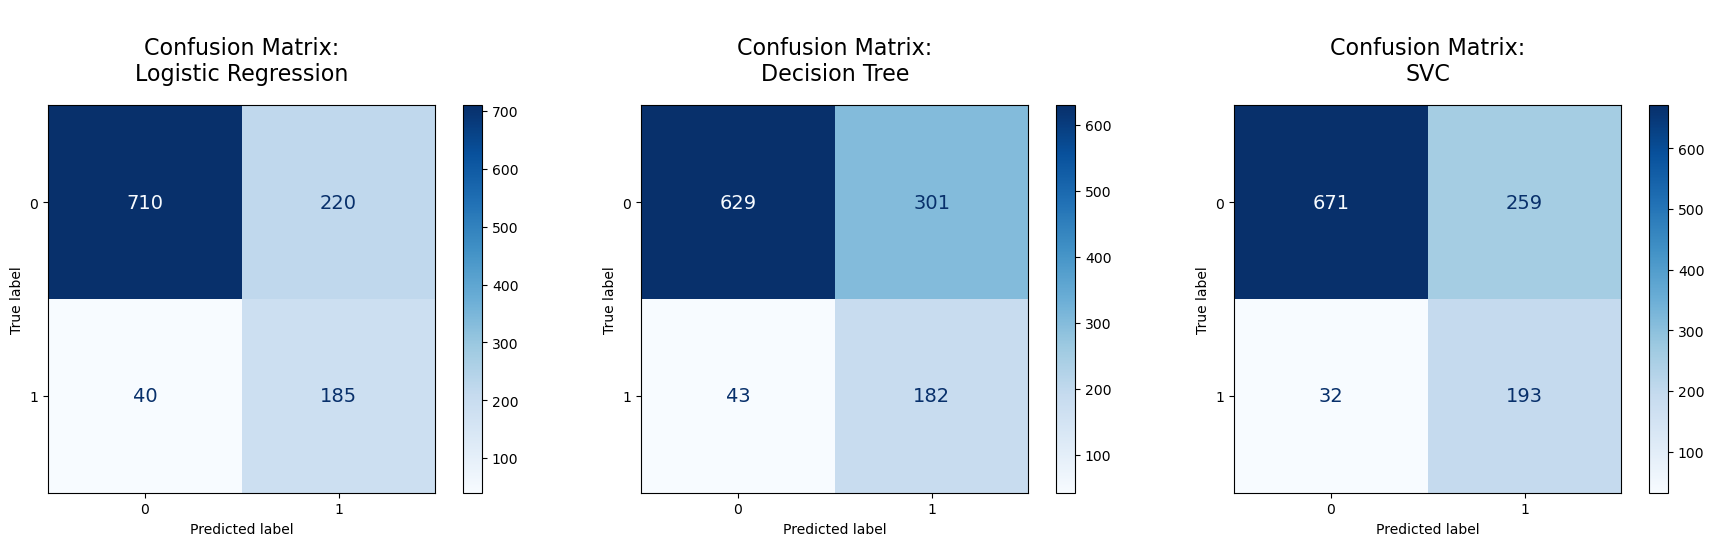

In [36]:
# Compare best_model of each model with a table of results, confusion matrices, and ROC curves.
best_models = {'Logistic Regression': lr_best_model, 'Decision Tree': dt_best_model, 'SVC': svc_best_model}
results = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    accuracy = f"{accuracy_score(y_test, y_pred):.4f}"
    recall = f"{recall_score(y_test, y_pred):.4f}"
    precision = f"{precision_score(y_test, y_pred):.4f}"
    f2 = f"{fbeta_score(y_test, y_pred, beta=2):.4f}"
    roc_auc = f"{roc_auc_score(y_test, y_pred):.4f}"
    
    results.append({'Model': name, 'Accuracy': accuracy, 'Recall': recall, 'Precision': precision, 'F2 Score': f2, 'ROC_AUC': roc_auc})



print("\nMODEL COMPARISON AFTER HYPERPARAMETER TUNING:\n")
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))#print(hpt_results_df.to_string(index=False))

# Compare the confusion matrix of each model.

tuned_models = [lr_best_model, dt_best_model, svc_best_model]
model_names = ['Logistic Regression', 'Decision Tree', 'SVC']

# 2. Setup the plot figure.
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # 1 row, 3 columns

# 3. Iterate to plot each confusion matrix.
for i, model in enumerate(tuned_models):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Create the display object.
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    # Plot on specific axis.
    disp.plot(ax=axes[i], cmap='Blues', text_kw={'fontsize':14})
    axes[i].set_title(f'\nConfusion Matrix:\n{model_names[i]}', fontsize=16, pad=18)

plt.tight_layout()
plt.show()

## Feature Importance

In [38]:
# Feature Importance
from sklearn.inspection import permutation_importance
# Create results dictionary
importance_results = {}

for name, model in best_models.items():
    result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=1)
    importance_results[name] = result.importances_mean

# Format results as a pandas DataFrame.
df_importance = pd.DataFrame(importance_results, index=X_test.columns)


FEATURE IMPORTANCE:

             Logistic Regression  Decision Tree       SVC
Type                    0.044156       0.058528  0.051082
Country                 0.040779       0.060693  0.046320
Year                    0.030390       0.049351  0.023810
Activity                0.015671       0.039827  0.013247
Species                 0.009784       0.004935  0.003723
Sex                    -0.001732      -0.002251 -0.002424
Age                    -0.000693       0.001991 -0.003636
Age_missing             0.002511      -0.002165 -0.006147


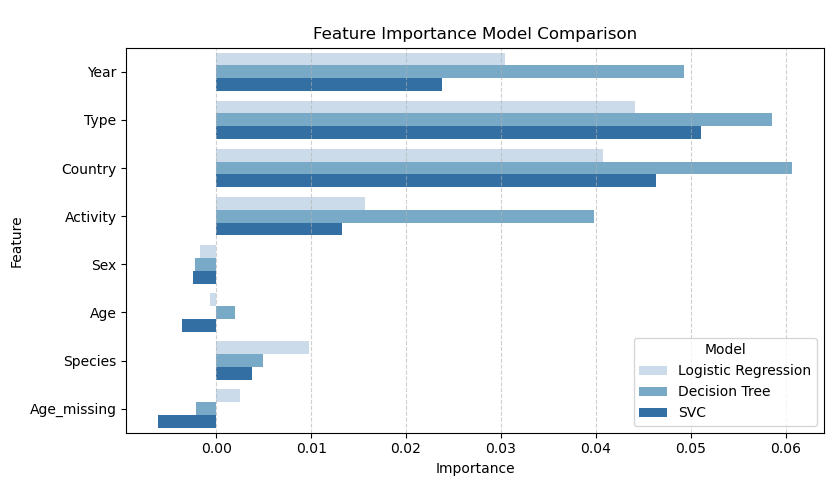

In [39]:
# Print and plot results.
print("\nFEATURE IMPORTANCE:\n")
print(df_importance.sort_values(by="SVC", ascending=False))

# Reshape the data for use in Seaborn (from "wide" to "long" format)
df_reshaped = df_importance.reset_index().melt(id_vars='index', var_name='Model', value_name='Importance')
df_reshaped.columns = ['Feature', 'Model', 'Importance']

# Plot using Seaborn
plt.figure(figsize=(9, 5))
sns.barplot(data=df_reshaped, x='Importance', y='Feature', hue='Model', palette='Blues')

plt.title('\nFeature Importance Model Comparison')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

## Final Model

### SVC is the model choice for it's higher recall and F2 scores, becasue of the high cost of false negatives.

In [42]:
# Check to see if recall can be improved by adjusting the decision threshold.
# Get raw decision scores.
y_scores = grid_search_svc.best_estimator_.decision_function(X_test)

# Lower the bar for what counts as a "Positive", default is 0.0
y_pred_aggressive = (y_scores > -0.2).astype(int) 

from sklearn.metrics import recall_score, precision_score
print(f"\nRecall at -0.2: {recall_score(y_test, y_pred_aggressive):.4f}")
print(f"Precision at -0.2: {precision_score(y_test, y_pred_aggressive):.4f}")


Recall at -0.2: 0.9022
Precision at -0.2: 0.4093



* * * * * FINAL MODEL RESULTS - SVC * * * * *

TEST SCORES:
Test Accuracy: 0.7273
Test Precision: 0.4093
Test Recall score: 0.9022
Test F2 score: 0.7271
Test ROC_AUC score: 0.7936


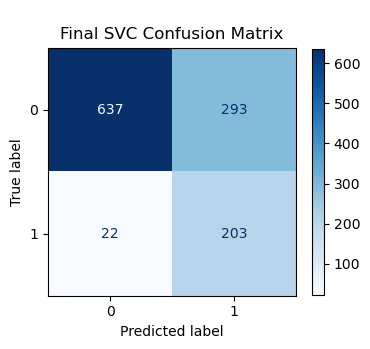

In [43]:
# 1. Finalize the chosen model
final_model = grid_search_svc.best_estimator_

# 2. Define the prediction function for SVC
def get_high_recall_preds(final_model, X, threshold=-0.2):
    
    scores = final_model.decision_function(X) #get the raw scores
    return (scores > threshold).astype(int) #apply the custom threshold

# 3. Use this instead of .predict() for all future data
y_final_pred = get_high_recall_preds(final_model, X_test)

print("\n\033[1;34m* * * * * FINAL MODEL RESULTS - SVC * * * * *\033[0m")
print_results(y_test, y_final_pred)

cm_svc = confusion_matrix(y_test, y_final_pred)
fig, ax = plt.subplots(figsize=(4, 4))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svc) 
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.colorbar(disp.im_, ax=ax, shrink=0.8)
plt.title("\nFinal SVC Confusion Matrix") 
plt.show()

In [44]:
# Create model card for final model

def create_model_card(model_name, model_details):
    """Generate a model card as a formatted string."""

    card = f"""
============================================================
MODEL CARD: {model_name}
============================================================

1. MODEL OVERVIEW
    - Model Type: {model_details['model_type']}
    - Version: {model_details['version']}
    - Date Trained: {model_details['date_trained']}
    - Purpose: {model_details['purpose']}
    
2. TRAINING DATA
    - Source: {model_details['data_source']}
    - Size: {model_details['data_size']}
    - Features: {model_details['features']}
    - Target: {model_details['target']}
    - Date Range: {model_details['data_date_range']}
    
3. PERFORMANCE METRICS
    - Accuracy: {model_details['accuracy']}
    - Precision: {model_details['precision']}
    - Recall: {model_details['recall']}
    - F2 Score: {model_details['f2_score']}
    - ROC-AUC: {model_details['roc_auc']}
    - Primary Metric: {model_details['primary_metric']}
    
4. INTENDED USE
    - Primary Use: {model_details['intended_use']}
    - Users: {model_details['intended_users']}
    - Out of Scope: {model_details['out_of_scope']}
    
5. LIMITATIONS & RISKS
    - Known Limitations: {model_details['limitations']}
    - Potential Biases: {model_details['biases']}
    - Risks: {model_details['risks']}
    
6. RECOMMENDATIONS
    - {model_details['recommendations']}
============================================================
"""
    return card

shark_model_details = {
    'model_type': 'Support Vector Machine: Support Vector Classification',
    'version': '1.0',
    'date_trained': '2026-03-07',
    'purpose': 'Predict likelihood that a shark incident results in a fatal outcome',
    'data_source': 'https://www.sharkattackfile.net/incidentlog.htm',
    'data_size': '5,771 incident reports (4616 train / 1155 test)',
    'features': 'Type, Country, Activity, Sex, Species, Year, Age, Age_missing(indicator or missing age)',
    'target': 'Binary fatal outcome (0=non-fatal incident, 1=fatal incident)',
    'data_date_range': '1900 - 2025',
    'accuracy': '0.7273',
    'precision': '0.4093',
    'recall': '0.9022',
    'f2_score': '0.7271',
    'roc_auc': '0.7936',
    'primary_metric': 'Recall (high cost of false negatives)',
    'intended_use': 'Identify situations where a shark incident has a high risk of resulting in a fatal outcome',
    'intended_users': 'Marine Tourism Stakeholders, Marine/Coastal Tourism Industry',
    'out_of_scope': 'Should not be used to predict whether a shark attack will occur, this model only predicts risk of fatality IF there is an attack',
    'limitations': 'Model trained on a subset of available features; additional features may significantly affect predicted outcomes',
    'biases': 'May underperform on countries placed in OTHER category',
    'risks': 'False negatives may underestimate risk of fatality in high risk situations',
    'recommendations': 'Retrain with additional available features, try removing features showing low importance, update model annually with new incident reports'
    }

print(create_model_card('Shark Attack Fatality Risk Predictor', shark_model_details))


MODEL CARD: Shark Attack Fatality Risk Predictor

1. MODEL OVERVIEW
    - Model Type: Support Vector Machine: Support Vector Classification
    - Version: 1.0
    - Date Trained: 2026-03-07
    - Purpose: Predict likelihood that a shark incident results in a fatal outcome
    
2. TRAINING DATA
    - Source: https://www.sharkattackfile.net/incidentlog.htm
    - Size: 5,771 incident reports (4616 train / 1155 test)
    - Features: Type, Country, Activity, Sex, Species, Year, Age, Age_missing(indicator or missing age)
    - Target: Binary fatal outcome (0=non-fatal incident, 1=fatal incident)
    - Date Range: 1900 - 2025
    
3. PERFORMANCE METRICS
    - Accuracy: 0.7273
    - Precision: 0.4093
    - Recall: 0.9022
    - F2 Score: 0.7271
    - ROC-AUC: 0.7936
    - Primary Metric: Recall (high cost of false negatives)
    
4. INTENDED USE
    - Primary Use: Identify situations where a shark incident has a high risk of resulting in a fatal outcome
    - Users: Marine Tourism Stakeholders